# Electronic spectrum of twisted bilayer graphene (Nori et al.)

This notebook presents a clean implementation based on the paper:

**A.O. Sboychakov, A.L. Rakhmanov, A.V. Rozhkov, Franco Nori**  
*Electronic spectrum of twisted bilayer graphene* (2015)  
[https://journals.aps.org/prb/abstract/10.1103/PhysRevB.92.075402](https://journals.aps.org/prb/abstract/10.1103/PhysRevB.92.075402)

**Original code author**  
Sarbajit Mazumdar  
Doctoral Researcher, Julius-Maximilians-Universitat Wurzburg  
Email: sarbajit.mazumdar@uni-wuerzburg.de

## Scope
- Build a commensurate twisted bilayer graphene lattice.
- Use a custom interlayer hopping with screening.
- Compute the band structure on a high-symmetry path.
- Estimate the band gap after centering the neutrality point.

## Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

from moirepy import BilayerMoireLattice, Layer

## Model parameters and graphene layer

Parameters used in this notebook:

$$
a = 2.46 \, \mathrm{\mathring{A}}, \qquad d = 3.35 \, \mathrm{\mathring{A}}, \qquad t = 2.57\,\text{eV}
$$

The tuples `ALPHA`, `BETA`, and `C_SCALE` are the interlayer-hopping model parameters used in the current code.

In [2]:
A_GRAPHENE = 2.46
D_SPACING = 3.35
ALPHA = (6.715, 0.762, 0.179, 1.411)
BETA = (6.811, 0.01, 19.176)
C_SCALE = 1.44
T_INTRA = 2.57


class Graphene(Layer):
    def __init__(self, pbc=False, study_proximity: int = 1) -> None:
        lv1 = np.array([1.0, 0.0]) * A_GRAPHENE
        lv2 = np.array([0.5, np.sqrt(3.0) / 2.0]) * A_GRAPHENE

        basis_points = [
            (0.0, 0.0, "A"),
            (A_GRAPHENE, A_GRAPHENE / np.sqrt(3.0), "B"),
        ]

        neigh_deltas = np.array([
            [0.0, 1.0 / np.sqrt(3.0)],
            [-0.5, -1.0 / (2.0 * np.sqrt(3.0))],
            [0.5, -1.0 / (2.0 * np.sqrt(3.0))],
        ]) * A_GRAPHENE

        neighbours = {"A": neigh_deltas, "B": -neigh_deltas}
        super().__init__(lv1, lv2, basis_points, neighbours, pbc, study_proximity)

## Build the commensurate twisted bilayer lattice

The active supercell choice below is `(ll1,ll2,ul1,ul2)=(1,2,2,1)`.

In [3]:
ll1, ll2, ul1, ul2 = 1, 2, 2, 1

lattice = BilayerMoireLattice(
    Graphene,
    ll1,
    ll2,
    ul1,
    ul2,
    n1=1,
    n2=1,
    pbc=True,
    translate_upper=(-A_GRAPHENE, -A_GRAPHENE / np.sqrt(3.0)),
)

lattice.generate_connections(inter_layer_radius=A_GRAPHENE / (2.0 * np.sqrt(3.0)))

twist angle = 0.3803 rad (21.7868 deg)
14 cells in upper lattice
14 cells in lower lattice


## Interlayer hopping model with screening

This section defines the screening function and interlayer coupling used by `tul`/`tlu` in Hamiltonian construction.

In [4]:
def screening_S(pos_i, pos_j, all_pos):
    rij = np.linalg.norm(pos_i - pos_j)
    ril = np.linalg.norm(all_pos - pos_i, axis=1)
    rjl = np.linalg.norm(all_pos - pos_j, axis=1)

    mask = (ril > 1e-6) & (rjl > 1e-6)
    x = ((ril[mask] + rjl[mask]) / rij).sum()
    xi = BETA[0] * np.exp(-BETA[1] * x**BETA[2])
    return np.tanh(xi)


def v_sigma(rij):
    r_scaled = C_SCALE * rij
    return ALPHA[0] * r_scaled ** (-ALPHA[1]) * np.exp(-ALPHA[2] * r_scaled ** ALPHA[3])


def t_perp_func(pos_u, pos_l, all_pos, d):
    rij = np.linalg.norm(pos_u - pos_l)
    inplane = np.linalg.norm(pos_u[:2] - pos_l[:2])
    cos_a = d / np.sqrt(d**2 + inplane**2)
    s_val = screening_S(pos_u, pos_l, all_pos)
    return (cos_a**2) * v_sigma(rij) * (1.0 - s_val)


def tul(pos_u, pos_l, R, type_u, type_l, lattice, d):
    lower_3d = np.column_stack([
        lattice.lower_lattice.bigger_points,
        np.zeros(len(lattice.lower_lattice.bigger_points)),
    ])
    upper_3d = np.column_stack([
        lattice.upper_lattice.bigger_points,
        np.full(len(lattice.upper_lattice.bigger_points), d),
    ])
    all_pos = np.vstack([lower_3d, upper_3d])

    vals = [
        t_perp_func(np.append(pu, d), np.append(pl, 0.0), all_pos, d)
        for pu, pl in zip(pos_u, pos_l + R)
    ]
    return np.array(vals)


def tlu(pos_l, pos_u, R, type_l, type_u, lattice, d):
    return np.conj(tul(pos_u, pos_l, R, type_u, type_l, lattice, d))

## Reciprocal lattice and k-path

High-symmetry path used here:

$$
\Gamma \to K_1 \to K_2 \to \Gamma
$$

In [5]:
def reciprocal_vectors(v1, v2):
    mat = np.column_stack([v1, v2])
    inv_t = 2.0 * np.pi * np.linalg.inv(mat).T
    return inv_t[:, 0], inv_t[:, 1]


g1, g2 = reciprocal_vectors(lattice.mlv1, lattice.mlv2)

gamma_point = np.zeros(2)
k1_point = (g1 + 2.0 * g2) / 3.0
k2_point = (2.0 * g1 + g2) / 3.0


def get_kpath(nseg):
    path_pts = [gamma_point, k1_point, k2_point, gamma_point]
    labels = [r"$\Gamma$", r"$K_1$", r"$K_2$", r"$\Gamma$"]

    k_list = []
    x_coords = []
    ticks = [0.0]
    tick_labels = [labels[0]]
    current_x = 0.0

    for i in range(len(path_pts) - 1):
        is_last = i == len(path_pts) - 2
        n_pts = nseg + 1 if is_last else nseg
        tvals = np.linspace(0.0, 1.0, n_pts, endpoint=is_last)

        segment = (1.0 - tvals)[:, None] * path_pts[i] + tvals[:, None] * path_pts[i + 1]
        k_list.extend(segment)
        x_coords.append(current_x + tvals)

        current_x = x_coords[-1][-1] + (0.0 if is_last else 1.0 / nseg)
        ticks.append(x_coords[-1][-1] if is_last else current_x - 1.0 / nseg)
        tick_labels.append(labels[i + 1])

    return np.array(k_list), np.concatenate(x_coords), ticks, tick_labels


k_points, x_ax, ticks, labels = get_kpath(100)

## Build and diagonalize the Hamiltonian along the k-path

In [6]:
ham_real_space = lattice.generate_hamiltonian(
    tll=-T_INTRA,
    tuu=-T_INTRA,
    tul=tul,
    tlu=tlu,
    extra_inputs={"d": D_SPACING},
).toarray()

all_energies = []
for kvec in tqdm(k_points, desc="Diagonalizing H(k)"):
    phase = lattice.get_phase(kvec).toarray()
    ham_k = ham_real_space * phase
    eigvals = np.linalg.eigvalsh(ham_k)
    all_energies.append(eigvals)

all_energies = np.array(all_energies)

Diagonalizing H(k): 100%|██████████| 301/301 [00:00<00:00, 11423.66it/s]


## Extract neutrality shift and estimate the gap

The two middle bands are used to estimate the valence-band maximum, conduction-band minimum, and gap.

In [7]:
mid_idx = all_energies.shape[1] // 2
lower_band = all_energies[:, mid_idx - 1]
upper_band = all_energies[:, mid_idx]

v_top = np.max(lower_band)
c_bottom = np.min(upper_band)
mu_shift = (v_top + c_bottom) / 2.0

gap = c_bottom - v_top
all_energies_shifted = all_energies - mu_shift

print(f"Chemical Potential Shift (mu): {mu_shift * 1e3:.2f} meV")
print(f"Calculated Band Gap: {gap * 1e3:.2f} meV")

Chemical Potential Shift (mu): 0.13 meV
Calculated Band Gap: 108.73 meV


## Plot the band structure

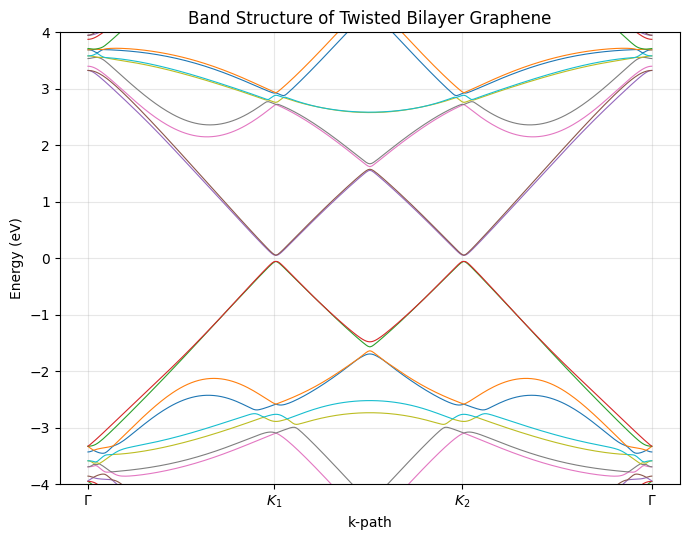

In [8]:
plt.figure(figsize=(7.0, 5.5))
plt.plot(x_ax, all_energies_shifted, lw=0.8)
plt.xticks(ticks, labels)
plt.xlabel("k-path")
plt.ylabel("Energy (eV)")
plt.ylim(-4.0, 4.0)
plt.title("Band Structure of Twisted Bilayer Graphene")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()